In [42]:
from pathlib import Path 
import os 
import sys
import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Util function 

In [43]:
def manual_filtering(df_dict, 
                     bounds, 
                     columns_to_keep, 
                     celltype_fraction, 
                     margin_frac_bounds, 
                     protocol_cols):
    
    # Filtered data frame 
    df_dict_filtered = {}
    df_dict_annotated = {}
    
    # Iterate over cell types 
    for cell_type in df_dict:
        # Collect cell type dictionary and sort by proportion 
        cell_type_revert_safe_string = cell_type.replace(":", "/")
        df_ct = df_dict[cell_type].copy()
        df_ct = df_ct.sort_values(by=f"{cell_type_revert_safe_string}_prop", ascending=False)
        
        # Subset data frame 
        columns_to_keep_ct = columns_to_keep + [f"{cell_type_revert_safe_string}_prop"]
        df_ct = df_ct.loc[:, columns_to_keep_ct]
        df_ct["filtering_step"] = "pass" 

        # Filter by fraction
        idx_lower = df_ct[f"{cell_type_revert_safe_string}_prop"] < celltype_fraction[cell_type_revert_safe_string] 
        df_ct.loc[idx_lower & (df_ct["filtering_step"] == "pass"), 
                  "filtering_step"] = "proportion_filter"

        # Oxygen and days filtering 
        idx_pass_oxygen_days = np.logical_and(df_ct["o2_[%]"] > 5, 
                                             df_ct["o2_[%]"] < 25)
        idx_pass_oxygen_days = np.logical_and(idx_pass_oxygen_days, 
                                             df_ct["days_of_culture"] > 12)
        idx_pass_oxygen_days = np.logical_and(idx_pass_oxygen_days, 
                                             df_ct["days_of_culture"] < 20)
        df_ct.loc[~idx_pass_oxygen_days & (df_ct["filtering_step"] == "pass"), 
                  "filtering_step"] = "oxygen_days"

        # Bounds 
        for param in protocol_cols:
            idx_bounds = np.logical_and(
                df_ct[param] >= (bounds[param][0] - bounds[param][0] * margin_frac_bounds), 
                df_ct[param] <= (bounds[param][1] + bounds[param][1] * margin_frac_bounds)
            )
            df_ct.loc[~idx_bounds & (df_ct["filtering_step"] == "pass"), 
                      "filtering_step"] = f"bounds_{param}"

        # Filtered dataset
        df_dict_filtered[cell_type] = df_ct[df_ct.filtering_step == "pass"]
        df_dict_annotated[cell_type] = df_ct[df_ct.filtering_step != "proportion_filter"]
        
    return df_dict_filtered, df_dict_annotated

## Read annotation file

In [44]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [45]:
ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

In [46]:
ubound_dict

{'gm-csf_[ng_ml]': 10.0,
 'tpo_[ng_ml]': 2.5,
 'um171_[nm]': 1120.0,
 'um729_[µm]': 1120.0,
 'sr1_[nm]': 750.0,
 'scf_[ng_ml]': 50.0,
 'butyzamide_[nm]': 100.0,
 'retinoic_acid_[µm]': 25.0,
 'ldl_[ng_ml]': 50.0,
 'il3_[ng_ml]': 20.0,
 'o2_[%]': 20.0,
 'days_of_culture': 18.0}

In [47]:
lbound_dict

{'gm-csf_[ng_ml]': 0.0,
 'tpo_[ng_ml]': 0.0,
 'um171_[nm]': 0.0,
 'um729_[µm]': 0.0,
 'sr1_[nm]': 0.0,
 'scf_[ng_ml]': 0.0,
 'butyzamide_[nm]': 0.0,
 'retinoic_acid_[µm]': 0.0,
 'ldl_[ng_ml]': 0.0,
 'il3_[ng_ml]': 0.0,
 'o2_[%]': 10.0,
 'days_of_culture': 12.0}

In [48]:
# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds

{'gm-csf_[ng_ml]': (0.0, 10.0),
 'tpo_[ng_ml]': (0.0, 2.5),
 'um171_[nm]': (0.0, 1120.0),
 'um729_[µm]': (0.0, 1120.0),
 'sr1_[nm]': (0.0, 750.0),
 'scf_[ng_ml]': (0.0, 50.0),
 'butyzamide_[nm]': (0.0, 100.0),
 'retinoic_acid_[µm]': (0.0, 25.0),
 'ldl_[ng_ml]': (0.0, 50.0),
 'il3_[ng_ml]': (0.0, 20.0),
 'o2_[%]': (10.0, 20.0),
 'days_of_culture': (12.0, 18.0)}

### Loop over solutions 

In [49]:
path_to_results = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/new_runs_mgkpro")
paths = os.listdir(path_to_results)

In [50]:
cell_types = ["MgkPro"]

In [51]:
pure_cell_type_solution_dict = {cell_type: [] 
                                for cell_type in cell_types
                               }

for experiment_folder in tqdm(paths):
    # Only consider pure populations 
    if "pure" in experiment_folder:
        cell_type_file_paths = path_to_results / experiment_folder
        # For all cell types 
        for cell_type in os.listdir(cell_type_file_paths):
            if cell_type=="MgkPro":
                config_exp_folders = cell_type_file_paths / cell_type
                # For all the experiments in the folders 
                for config_exp_folder in os.listdir(config_exp_folders):
                    # Be sure candidates are there 
                    if "candidates.csv" in os.listdir(config_exp_folders / config_exp_folder):
                        candidate_path = config_exp_folders / config_exp_folder / "candidates.csv"
                        candidate_df = pd.read_csv(candidate_path)
                        candidate_df["run_name"] = [file.split("/")[-1] for file in candidate_df["cfg:paths:dump_dir"]]
                        pure_cell_type_solution_dict[cell_type].append(candidate_df)

100%|██████████| 6/6 [00:12<00:00,  2.15s/it]


In [52]:
# Concatenate data frame 
pure_cell_type_solution_dict_concat = {
    key: pd.concat(val, axis=0) for key, val in pure_cell_type_solution_dict.items()
}

In [53]:
pure_cell_type_solution_dict_concat["MgkPro"]

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,MgkPro:2026-03-12_17-04-39_221b4785:0,7.126898,0.000000,524.30720,14.310798,0.240438,21.832958,15.099325,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MgkPro:2026-03-12_17-04-39_221b4785:1,14.098056,9.074765,3249.76030,195.162340,0.000000,31.863394,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MgkPro:2026-03-12_17-04-39_221b4785:2,12.130225,0.547647,97.26468,47.630554,6.110730,7.734135,0.000000,2.466211,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MgkPro:2026-03-12_17-04-39_221b4785:3,11.894924,2.152432,567.81890,1.018503,25.047798,7.023629,36.114155,0.106266,2.545905,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MgkPro:2026-03-12_17-04-39_221b4785:4,18.310776,5.893925,81.26710,45.181250,0.000000,18.032204,0.474950,1.604604,4.767726,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,MgkPro:2026-03-12_17-46-28_3c04b980:95,15.537278,0.000000,1129.10190,153.097530,0.000000,13.590465,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,MgkPro:2026-03-12_17-46-28_3c04b980:96,0.609698,0.000000,204.55843,52.408154,0.839969,3.252890,7.866806,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,MgkPro:2026-03-12_17-46-28_3c04b980:97,37.419860,0.000000,1394.03530,54.036810,0.000000,16.242945,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,MgkPro:2026-03-12_17-46-28_3c04b980:98,75.201355,1.416241,285.02176,284.180660,0.289118,31.752111,1.007647,0.777592,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
for col in pure_cell_type_solution_dict_concat["MgkPro"].columns:
    print(col)

sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
loss
CD14-Mono_prop
CD49c-Myeloid_prop
CyclingProgenitor*_prop
DCs-CD14_prop
EarlyGMP_prop
Early_Pro-B_prop
EosBasoMastPre_prop
EosBasoMastPre_2_prop
EryPro_prop
GMP-Cycle_prop
GMP-Neutro_prop
GMP-Neutro/CD16-Mono_prop
HSCs_prop
MEP_prop
MLP_prop
MPP_prop
MgkPro_prop
Pro-B_prop
pDCs/cDCs_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:protocol_sep
cfg:annotation:one_hot_uns_key_added
cfg:annotation:protocol_obsm_key
cfg:annotation:scatter_columns
cfg:annotation:base_sample_rep
cfg:annotation:scatter_obsm_key
cfg:annotation:concat_

In [55]:
# Cell type fractions
celltype_fraction = {
    "MgkPro": 0.15
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "loss", 
    # "target_ct_loss_std",
    # "target_ct_loss_mean",
    # "ct_prop_total_variance",
    # "exploitation_score",
    # "exploration_score",
    # "weighted_uncertainty_score",
    # "metric_response_surface"
]

### Filter values

In [56]:
# Collect filtered and annotated data frames 
filtered_df, annotated_df = manual_filtering(
    df_dict=pure_cell_type_solution_dict_concat,
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0.5, 
    protocol_cols=protocol_cols
)

In [57]:
# Filtered and unfiltered solutions 
for ct in filtered_df:
    print(f"Filtered {ct} number of solutions:", filtered_df[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", pure_cell_type_solution_dict_concat[ct].shape[0], "\n")

Filtered MgkPro number of solutions: 312
Unfiltered MgkPro number of solutions: 25300 



In [58]:
annotated_df

{'MgkPro':     gm-csf_[ng_ml]  tpo_[ng_ml]    sr1_[nm]  um171_[nm]  um729_[µm]  \
 67       10.009178     0.606719   49.880226    0.000317    0.000000   
 67       10.010179     1.863149   83.659256    0.000000    0.000000   
 67       10.009436     1.272390   74.382250    0.000000    0.000085   
 67       10.017552     1.807842   91.998140    0.000000    0.000000   
 79       93.508910     3.645313   95.507630    0.000000    0.000000   
 ..             ...          ...         ...         ...         ...   
 75        0.000000     0.000000   14.404264   21.452860    0.000000   
 75        0.000000     0.000000   14.404264   21.452860    0.000000   
 56        0.000000    28.357067  128.297120  326.053560    0.521771   
 75        0.000000     0.000000   16.323677   30.458523    0.432003   
 75        0.000000     0.000000   16.323677   30.458523    0.432003   
 
     scf_[ng_ml]  butyzamide_[nm]  retinoic_acid_[µm]  ldl_[ng_ml]  \
 67     5.284710         0.723684            2.719543 

## Downstream

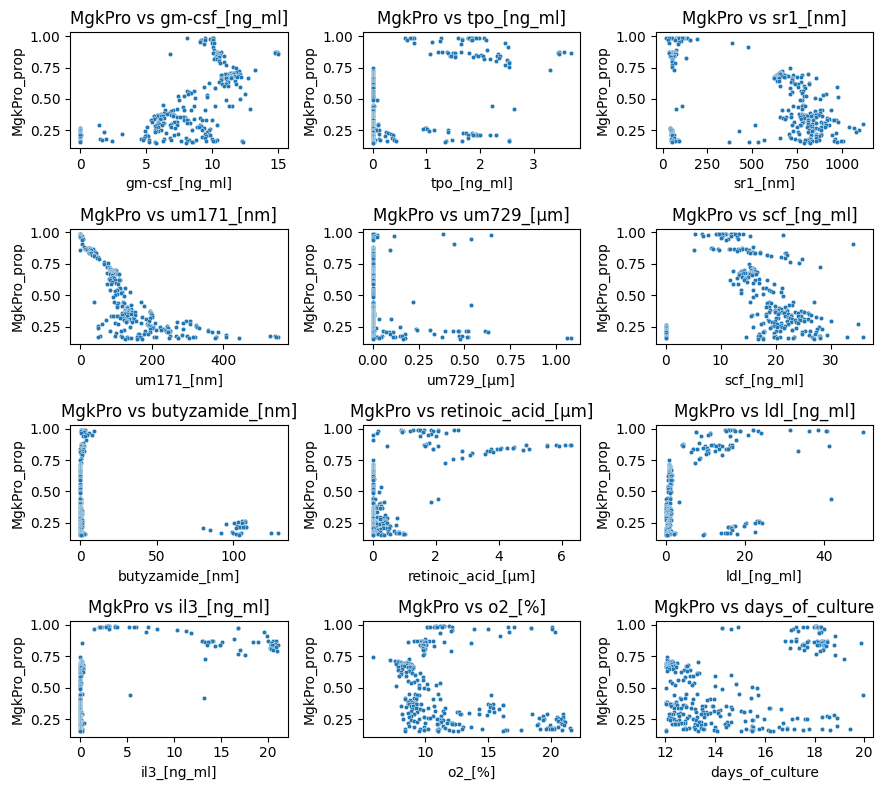

In [59]:
for cell_type in filtered_df:
    # Cell type safe
    cell_type_safe = cell_type.replace(":", "/")
    
    n_params = len(protocol_cols)
    ncols = 3  # adjust as you like
    nrows = math.ceil(n_params / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 2*nrows))
    axes = axes.flatten()  # make indexing easy

    for i, param in enumerate(protocol_cols):
        sns.scatterplot(
            data=filtered_df[cell_type],
            x=param,
            y=f"{cell_type_safe}_prop",
            ax=axes[i], 
            s=10
        )
        axes[i].set_title(f"{cell_type} vs {param}")

    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [60]:
0,
0,
0,
70,
0,
0,
100,
0, 
0,
0,
20,
14

14

In [61]:
protocol_cols

['gm-csf_[ng_ml]',
 'tpo_[ng_ml]',
 'sr1_[nm]',
 'um171_[nm]',
 'um729_[µm]',
 'scf_[ng_ml]',
 'butyzamide_[nm]',
 'retinoic_acid_[µm]',
 'ldl_[ng_ml]',
 'il3_[ng_ml]',
 'o2_[%]',
 'days_of_culture']

In [208]:
# path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge"

In [21]:
# sakurai_medium = np.array([0, 0, 0, 70, 0, 0, 100, 0, 0, 0, 20, 14])

In [22]:
# dict(zip(protocol_cols, sakurai_medium))

In [23]:
# MgkPro_df = filtered_df["MgkPro"]

In [61]:
# dist_mgkpro_sakurai = np.abs(MgkPro_df.loc[:, protocol_cols].values - sakurai_medium[None, :]).sum(1)

In [62]:
# np.argmin(dist_mgkpro_sakurai)

In [63]:
# MgkPro_df.iloc[979]

In [64]:
# distances_from_sakurai_per_cell_type = {}

# for cell_type in filtered_df:
#     df_cell_type = filtered_df[cell_type]
#     distances_from_sakurai_per_cell_type[cell_type] = np.abs(df_cell_type.loc[:, protocol_cols].values - sakurai_medium[None, :]).sum(1)

In [71]:
# for cell_type in distances_from_sakurai_per_cell_type:
#     plt.figure(figsize=(3,3))
#     sns.histplot(distances_from_sakurai_per_cell_type[cell_type])
#     print(np.min(distances_from_sakurai_per_cell_type[cell_type]))
#     plt.title(cell_type)
#     plt.show()

## Check uncertainties at every filtering step 

In [80]:
# def annotate_filtering_steps(): 

In [81]:
# for cell_type in pure_cell_type_solution_dict_concat:
#     cell_type_safe = cell_type.replace(":", "/")

#     df_plot = pure_cell_type_solution_dict_concat[cell_type].reset_index(drop=True)

#     plt.figure(figsize=(2,2))
#     sns.scatterplot(
#         data=df_plot,
#         x=f"{cell_type_safe}_prop",
#         y="target_ct_loss_std",
#         edgecolor="black"
#     )
#     plt.show()

## Compare uncertainty of solutions that make the cut 

In [104]:
# for cell_type in annotated_df:

#     df_plot = annotated_df[cell_type].reset_index(drop=True)

#     plt.figure(figsize=(2.8, 3.2))

#     ax = sns.boxplot(
#         data=df_plot,
#         x="filtering_step",
#         y="target_ct_loss_std",
#         hue="filtering_step", 
#         order=["proportion_filter", "oxygen_days", "bounds", "pass"],
#         width=0.6,
#         fliersize=1,
#         palette="colorblind"
#     )

#     # Clean aesthetics
#     sns.despine()
#     ax.set_xlabel("")
#     ax.set_ylabel("Target CT loss (std)")
#     ax.set_title(cell_type, fontsize=10)

#     plt.xticks(rotation=90, ha="right")
#     plt.tight_layout()
#     plt.show()

TODO:
* Compare with Sakurai
* Same analysis with custom (HSCs, MgkPro, EryPro)
* Uncertainty calibration 

In [72]:
# annotated_df["Early_Pro-B"]["filtering_step"].value_counts()

In [73]:
# annotated_df["HSCs"]["filtering_step"].value_counts()

In [74]:
# annotated_df["Early_Pro-B"].max(0)

In [75]:
# bounds

In [76]:
# for t_warmup, vmin, vmax in zip(filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
#     print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

In [77]:
# for t_warmup, vmin, vmax in zip(filtered_df["HSCs"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["HSCs"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
#     print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

In [78]:
# for t_warmup, vmin, vmax in zip(filtered_df["Pro-B"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["Early_Pro-B"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
#     print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

In [79]:
# for t_warmup, vmin, vmax in zip(filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:t_warmup"], filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:vmax"], filtered_df["EryPro"]["cfg:constraints:c_scheduler_kwargs:vmin"]):
#     print("t_warmup:", t_warmup, "vmin:", vmin, "vmax:", vmax)

In [80]:
# filtered_df["EryPro"]["run_name"].value_counts()

In [81]:
# filtered_df["EryPro"][filtered_df["EryPro"]["EryPro_prop"]>0.40].loc[:, protocol_cols]

## Check values of penalization parameters

In [82]:
# sns.histplot(data=filtered_df["Early_Pro-B"],
#              x="cfg:constraints:c_scheduler_kwargs:t_warmup")
# plt.show()

# sns.histplot(data=filtered_df["Early_Pro-B"],
#              x="cfg:constraints:c_scheduler_kwargs:vmin")
# plt.show()

# sns.histplot(data=filtered_df["Early_Pro-B"],
#              x="cfg:constraints:c_scheduler_kwargs:vmax")
# plt.show()

In [83]:
# sns.histplot(data=filtered_df["HSCs"],
#              x="cfg:constraints:c_scheduler_kwargs:t_warmup")
# plt.show()

# sns.histplot(data=filtered_df["HSCs"],
#              x="cfg:constraints:c_scheduler_kwargs:vmin")
# plt.show()

# sns.histplot(data=filtered_df["HSCs"],
#              x="cfg:constraints:c_scheduler_kwargs:vmax")
# plt.show()

In [84]:
# sns.histplot(data=filtered_df["Pro-B"],
#              x="cfg:constraints:c_scheduler_kwargs:t_warmup")
# plt.show()

# sns.histplot(data=filtered_df["Pro-B"],
#              x="cfg:constraints:c_scheduler_kwargs:vmin")
# plt.show()

# sns.histplot(data=filtered_df["Pro-B"],
#              x="cfg:constraints:c_scheduler_kwargs:vmax")
# plt.show()

## Check HSCs

In [85]:
# hsc = annotated_df["HSCs"]

In [86]:
# hsc = hsc[hsc["HSCs_prop"]>0.20]

In [87]:
# hsc["HSCs_prop"]

In [88]:
# annotated_df["HSCs"]["filtering_step"].value_counts()

In [89]:
# plt.hist(annotated_df["HSCs"]["o2_[%]"], 50)

## Read new dataset

In [61]:
# adata_new = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/miscellaneous/ds_HID01_logicle_100k_UMAP_ann_with_LPHO12.h5ad")

In [62]:
# for experiment in ["205", "206", "207", "208", "209", "210"]:
#     adata_new_copy = adata_new.copy()
#     sc.pl.umap(adata_new_copy, color="experiment_number", groups=[experiment], palette="r")

In [63]:
# sc.tl.pca(adata_new)
# sc.pp.neighbors(adata_new)
# sc.tl.umap(adata_new)

In [64]:
# for experiment in ["205", "206", "207", "208", "209", "210"]:
#     adata_new_copy = adata_new.copy()
#     sc.pl.umap(adata_new_copy, color="experiment_number", groups=[experiment], palette="r", s=10)

In [65]:
# sc.pl.umap(adata_new_copy, color="cell_type", s=12)

In [65]:
from sc_exp_design.models import FlowMatching

In [66]:
model = FlowMatching.load("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-03-09_13-54-17/polar-grass-4_FlowMatching.pkl")

In [72]:
model.train_data.perturbation_data["repr_protocol_mapped_protocol_mapped_repr"].max(0)

array([2.39789527, 1.25276297, 6.62140565, 7.02197642, 7.02197642,
       3.93182563, 4.61512052, 3.25809654, 3.93182563, 3.04452244,
       3.04452244, 3.61091791])